## Download NASA ICESat-2 ATL 06 Data ##

This notebook draws heavily on code from the NSIDC-Data-Tutorials: https://github.com/nsidc/NSIDC-Data-Tutorials


In [1]:
#read in dependencies
import earthaccess
import xarray as xr
import hvplot.xarray
import pprint
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# log in to Earthdata
earthaccess.login(strategy="interactive", persist=True)

In [ ]:
    #For preliminary exploration, focus on data from Lake Vostok - stable subglacial lake 
#Lake Vostok - 77.5 S, 106.0 E 

granules = earthaccess.search_data(
    short_name = 'ATL06',
    version = '007',
    cloud_hosted = True,
    bounding_box=(105.5, -78.5, 107.0, -77.5),  # west, south, east, north
    temporal = ('2018-10-14','2019-10-14'),
)

len(granules)

# In the full range of 2018-10-14 to 2025-03-02, there are 428 files available for Lake Vostok
    #Therefore, we will reduce the time range to limit the number of files (at this point)

83

In [4]:
data_dir = Path("/Users/sofiasuhinin/Desktop/MLGEO_Subglacial_Lakes/ATL06_LakeVostok/")

#earthaccess.download(granules, local_path=data_dir) #commented out to avoid re-downloading files

### ATL06 v007 File Contents ###


In [5]:
#sort atl06 files in data directoy 
atl_06 = sorted(data_dir.rglob("*.h5"))

#check structure of first file in directory 
dt = xr.open_datatree(atl_06[0], phony_dims="sort")
list(dt.keys())

/var/folders/3r/pr708byx3wq5670k7_scfc240000gn/T/ipykernel_19270/1428529230.py:5: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dt = xr.open_datatree(atl_06[0], phony_dims="sort")
/var/folders/3r/pr708byx3wq5670k7_scfc240000gn/T/ipykernel_19270/1428529230.py:5: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedel

['ancillary_data',
 'orbit_info',
 'quality_assessment',
 'METADATA',
 'gt1l',
 'gt1r',
 'gt2l',
 'gt2r',
 'gt3l',
 'gt3r']

In [7]:
BEAMS = ["gt1l", "gt1r", "gt2l", "gt2r", "gt3l", "gt3r"]

beam_dfs = []

for f in atl_06: #for every file in atl_06 
    for beam in BEAMS: #loop over each BEAM (see cell above)
        try:
            ds = xr.open_dataset(f, group=f"{beam}/land_ice_segments", engine="h5netcdf") #open any BEAM for given file

            beam_df = ds[["h_li", "h_li_sigma", "delta_time", "latitude", "longitude"]].to_dataframe().reset_index() #select wanted variables - can change this later if we want!

            beam_df["time"] = beam_df["delta_time"] #rename delta_time to time 

            beam_df["beam"] = beam #add column with beam name
            beam_df["file"] = f.name #add column with file name

# drop NaN values for select columns
            beam_df = beam_df[["time", "h_li", "h_li_sigma", "latitude", "longitude", "beam", "file"]].dropna(
                subset=["h_li", "h_li_sigma", "time"]
            )

            beam_dfs.append(beam_df)

#if error in loop print failed file name and base 
        except Exception as e:
            print("failed file:", f.name, beam, "->", e)
            continue

#stacks all the dfs into one big df
df = pd.concat(beam_dfs, ignore_index=True)
df.head()


,time,h_li,h_li_sigma,latitude,longitude,beam,file
0,2018-10-14 09:08:46.073725968,3431.547607,0.020181,-79.001062,106.692854,gt1l,ATL06_20181014090846_02400112_007_01.h5
1,2018-10-14 09:08:46.076544524,3431.559326,0.020670,-79.000887,106.692676,gt1l,ATL06_20181014090846_02400112_007_01.h5
2,2018-10-14 09:08:46.079358620,3431.631348,0.023912,-79.000712,106.692498,gt1l,ATL06_20181014090846_02400112_007_01.h5
3,2018-10-14 09:08:46.082170100,3431.665771,0.016677,-79.000537,106.692321,gt1l,ATL06_20181014090846_02400112_007_01.h5
4,2018-10-14 09:08:46.084979808,3431.656738,0.021621,-79.000362,106.692143,gt1l,ATL06_20181014090846_02400112_007_01.h5


In [11]:
df

,time,h_li,h_li_sigma,latitude,longitude,beam,file
0,2018-10-14 09:08:46.073725968,3431.547607,0.020181,-79.001062,106.692854,gt1l,ATL06_20181014090846_02400112_007_01.h5
1,2018-10-14 09:08:46.076544524,3431.559326,0.020670,-79.000887,106.692676,gt1l,ATL06_20181014090846_02400112_007_01.h5
2,2018-10-14 09:08:46.079358620,3431.631348,0.023912,-79.000712,106.692498,gt1l,ATL06_20181014090846_02400112_007_01.h5
3,2018-10-14 09:08:46.082170100,3431.665771,0.016677,-79.000537,106.692321,gt1l,ATL06_20181014090846_02400112_007_01.h5
4,2018-10-14 09:08:46.084979808,3431.656738,0.021621,-79.000362,106.692143,gt1l,ATL06_20181014090846_02400112_007_01.h5
...,...,...,...,...,...,...,...
31639544,2019-10-12 15:51:45.007300512,-2.544951,0.044837,-64.992891,99.842039,gt3r,ATL06_20191012154802_02400512_007_01.h5
31639545,2019-10-12 15:51:45.010106832,-2.538478,0.033528,-64.992712,99.841993,gt3r,ATL06_20191012154802_02400512_007_01.h5
31639546,2019-10-12 15:51:45.015775616,-2.494472,0.051803,-64.992353,99.841898,gt3r,ATL06_20191012154802_02400512_007_01.h5
31639547,2019-10-12 15:51:45.018584784,-2.491201,0.044077,-64.992176,99.841851,gt3r,ATL06_20191012154802_02400512_007_01.h5


### Preliminary Data Visualisation ###
- What does it look like raw?
- Does it need to be resampled? - yes...

NEXT STEPS:
 - Need to cut longitude and latitude to define the lake shape better
 - Compare this to a unstable lake - historically Lake Vostok is stable 
 - Expand time scale - just did 1 year to avoid data overload 

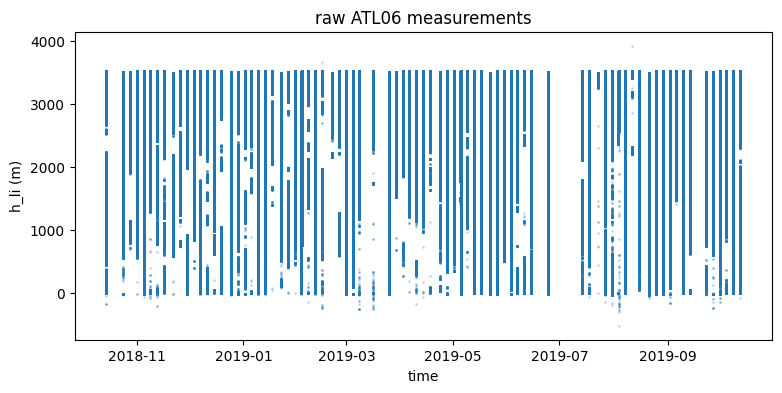

In [ ]:
# raw points
plt.figure(figsize=(9,4))
plt.scatter(df.time, df.h_li, s=1, alpha=0.2)
plt.ylabel("h_li (m)")
plt.xlabel("time")
plt.title("raw ATL06 measurements")
plt.show()

#great! - need to sample 

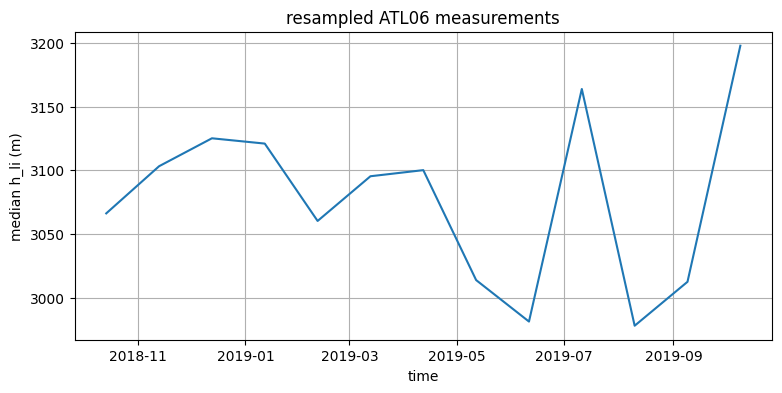

In [17]:
#resample data to median every 30 days? 60 days? 
resample = df.set_index("time").resample("30D").median(numeric_only=True).reset_index()

plt.figure(figsize=(9,4))
plt.plot(resample["time"], resample["h_li"])
plt.ylabel("median h_li (m)")
plt.xlabel("time")
plt.title("resampled ATL06 measurements")
plt.grid(True)
plt.show()


In [ ]:
# next step --> define the exact region of Lake Vostok to see if we can see the changes of surface height over time...